# CART MODELS FOR CREDIT EVALUATION

## IMPORTS AND DATA PREPARATION

### IMPORTS

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import ParameterGrid
from IPython.display import display
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

### PATHS

In [2]:
OUTPUT_DIR = Path("../data")
TRAIN_PATH = OUTPUT_DIR / "train.csv"
VALIDATE_PATH = OUTPUT_DIR / "validate.csv"
TEST_PATH = OUTPUT_DIR / "test.csv"

CART_OUTPUT_DIR = Path("../output/cart")
CART_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VALIDATION_COMPARE_CSV = CART_OUTPUT_DIR / "cart_validation_comparison.csv"
TEST_COMPARE_CSV = CART_OUTPUT_DIR / "cart_test_comparison.csv"
CART_BUSINESS_SUMMARY_CSV = CART_OUTPUT_DIR / "cart_business_summary.csv"
FIXED_APPROVAL_COMPARE_CSV = CART_OUTPUT_DIR / "cart_business_fixed_approval_rate_comparison.csv"
FIXED_BAD_RATE_COMPARE_CSV = CART_OUTPUT_DIR / "cart_business_fixed_bad_rate_comparison.csv"


In [3]:
# Load data splits to pandas
train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
validate_df = pd.read_csv(VALIDATE_PATH, low_memory=False)
test_df = pd.read_csv(TEST_PATH, low_memory=False)

# Compute Mean Credit Amount for Business Translation Logic
MEAN_CREDIT_AMOUNT = train_df['AMT_CREDIT'].mean()
print(f"Mean Credit Amount (Train): ${MEAN_CREDIT_AMOUNT:,.2f}")

TARGET_COLUMN = "TARGET"
ID_COLUMN = "SK_ID_CURR"


Mean Credit Amount (Train): $599,184.06


### PREP DATA FOR MODEL TRAINING

In [4]:
# Separate labels y
y_train = train_df[TARGET_COLUMN].astype(int).copy()
y_val = validate_df[TARGET_COLUMN].astype(int).copy()
y_test = test_df[TARGET_COLUMN].astype(int).copy()

# Remove labels and IDs to prep samples for training
X_train = train_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_val = validate_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_test = test_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()

# Convert categorical to one-hot encodings
categorical_columns = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

X_train_encoded = pd.get_dummies(X_train, columns=categorical_columns, drop_first=False, dtype=int)
X_val_encoded = pd.get_dummies(X_val, columns=categorical_columns, drop_first=False, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_columns, drop_first=False, dtype=int)

X_train_ready = X_train_encoded.copy()
X_val_ready = X_val_encoded.reindex(columns=X_train_ready.columns, fill_value=0)
X_test_ready = X_test_encoded.reindex(columns=X_train_ready.columns, fill_value=0)

# Impute for Scikit-Learn tree compatibility
imputer = SimpleImputer(strategy='median')
X_train_ready = pd.DataFrame(imputer.fit_transform(X_train_ready), columns=X_train_ready.columns)
X_val_ready = pd.DataFrame(imputer.transform(X_val_ready), columns=X_val_ready.columns)
X_test_ready = pd.DataFrame(imputer.transform(X_test_ready), columns=X_test_ready.columns)


## EVALUATION METRICS

In [5]:
def compute_ks(y_true, y_score):
    df_ks = pd.DataFrame({"y_true": pd.Series(y_true).reset_index(drop=True), "y_score": pd.Series(y_score).reset_index(drop=True)})
    df_ks = df_ks.sort_values("y_score", ascending=False).reset_index(drop=True)
    total_positives = (df_ks["y_true"] == 1).sum()
    total_negatives = (df_ks["y_true"] == 0).sum()
    if total_positives == 0 or total_negatives == 0: return np.nan
    df_ks["cum_positives"] = (df_ks["y_true"] == 1).cumsum() / total_positives
    df_ks["cum_negatives"] = (df_ks["y_true"] == 0).cumsum() / total_negatives
    return np.max(np.abs(df_ks["cum_positives"] - df_ks["cum_negatives"]))

def evaluate_binary_model(model, X, y, split_name, model_name):
    y_proba = model.predict_proba(X)[:, 1]
    return {
        "model_name": model_name,
        "split": split_name,
        "roc_auc": roc_auc_score(y, y_proba),
        "pr_auc": average_precision_score(y, y_proba),
        "brier_score": brier_score_loss(y, y_proba),
        "ks_stat": compute_ks(y, y_proba)
    }

def evaluate_operating_point(y_true, y_score, approval_rate=None, bad_rate_target=None):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(y_score)
    sorted_y_true = y_true[order]
    sorted_y_score = y_score[order]
    n_obs = len(sorted_y_true)

    if approval_rate is not None and bad_rate_target is None:
        n_approve = int(np.floor(approval_rate * n_obs))
        n_approve = max(1, min(n_approve, n_obs))
    elif bad_rate_target is not None and approval_rate is None:
        cumulative_defaults = np.cumsum(sorted_y_true)
        candidate_counts = np.arange(1, n_obs + 1)
        cumulative_bad_rates = cumulative_defaults / candidate_counts
        feasible_counts = candidate_counts[cumulative_bad_rates <= bad_rate_target]
        if len(feasible_counts) == 0:
            n_approve = 1
        else:
            n_approve = int(feasible_counts[-1])
    else:
        raise ValueError("Set exactly one of approval_rate or bad_rate_target.")

    approved_y_true = sorted_y_true[:n_approve]
    approved_y_score = sorted_y_score[:n_approve]
    rejected_y_true = sorted_y_true[n_approve:]

    approved_defaults = int(approved_y_true.sum())
    approved_nondefaults = int(len(approved_y_true) - approved_defaults)
    rejected_defaults = int(rejected_y_true.sum())
    rejected_nondefaults = int(len(rejected_y_true) - rejected_defaults)
    
    observed_bad_rate_among_approved = approved_defaults / len(approved_y_true) if len(approved_y_true) else 0.0
    realized_approval_rate = len(approved_y_true) / n_obs
    approval_threshold = approved_y_score[-1] if len(approved_y_score) else 0.0

    return {
        "n_total_applicants": n_obs,
        "n_approved": len(approved_y_true),
        "n_rejected": len(rejected_y_true),
        "approval_rate": realized_approval_rate,
        "approved_defaults": approved_defaults,
        "approved_nondefaults": approved_nondefaults,
        "rejected_defaults": rejected_defaults,
        "rejected_nondefaults": rejected_nondefaults,
        "observed_bad_rate_among_approved": observed_bad_rate_among_approved,
        "approval_threshold": approval_threshold
    }

def plot_roc_curves(curves_dict, title):
    plt.figure(figsize=(8, 6))
    for label, (y_true, y_proba) in curves_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc_score(y_true, y_proba):.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_pr_curves(curves_dict, title):
    plt.figure(figsize=(8, 6))
    for label, (y_true, y_proba) in curves_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        plt.plot(recall, precision, label=f"{label} (PR-AUC = {average_precision_score(y_true, y_proba):.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


## UNCONSTRAINED BASELINE

In [6]:
cart_baseline = DecisionTreeClassifier(
    max_depth=5,              # Conservative baseline
    min_samples_leaf=100,
    class_weight="balanced",
    random_state=42
)
cart_baseline.fit(X_train_ready, y_train)

baseline_val_prob = cart_baseline.predict_proba(X_val_ready)[:, 1]
baseline_val_result = evaluate_binary_model(cart_baseline, X_val_ready, y_val, "validation", "cart_unconstrained_baseline")
print("Unconstrained Baseline validation results:", baseline_val_result)


Unconstrained Baseline validation results: {'model_name': 'cart_unconstrained_baseline', 'split': 'validation', 'roc_auc': np.float64(0.7137195984815967), 'pr_auc': np.float64(0.18034638438552714), 'brier_score': np.float64(0.21357309255938622), 'ks_stat': 0.3164650113185666}


## UNCONSTRAINED TUNED

In [7]:
param_grid = {
    'max_depth': [6, 8, 10, 12],
    'min_samples_leaf': [100, 200, 500]
}

best_pr_auc = -1
best_cart_unconstrained = None
search_results = []

for params in ParameterGrid(param_grid):
    clf = DecisionTreeClassifier(**params, class_weight="balanced", random_state=42)
    clf.fit(X_train_ready, y_train)
    
    model_lbl = f"cart_unconstrained_d{params['max_depth']}_l{params['min_samples_leaf']}"
    val_res = evaluate_binary_model(clf, X_val_ready, y_val, "validation", model_lbl)
    search_results.append(val_res)
    
    if val_res['pr_auc'] > best_pr_auc:
        best_pr_auc = val_res['pr_auc']
        best_cart_unconstrained = clf

search_results_df = pd.DataFrame(search_results).sort_values(by='pr_auc', ascending=False)
display(search_results_df.head(3))

tuned_val_prob = best_cart_unconstrained.predict_proba(X_val_ready)[:, 1]
tuned_val_result = evaluate_binary_model(best_cart_unconstrained, X_val_ready, y_val, "validation", "cart_unconstrained_tuned")
print("Unconstrained Tuned validation results:", tuned_val_result)


,model_name,split,roc_auc,pr_auc,brier_score,ks_stat
7,cart_unconstrained_d10_l200,validation,0.712659,0.197081,0.208153,0.322845
8,cart_unconstrained_d10_l500,validation,0.719812,0.197064,0.208937,0.327612
10,cart_unconstrained_d12_l200,validation,0.710856,0.197047,0.206834,0.319043


Unconstrained Tuned validation results: {'model_name': 'cart_unconstrained_tuned', 'split': 'validation', 'roc_auc': np.float64(0.7126594920768131), 'pr_auc': np.float64(0.19708107599367042), 'brier_score': np.float64(0.2081526968223992), 'ks_stat': 0.32284464367300225}


## CONSTRAINED TUNED

In [8]:
EXT_SOURCE_COLUMNS = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
mono_cst = []
for col in X_train_ready.columns:
    if col in EXT_SOURCE_COLUMNS or col in ['AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED']:
        mono_cst.append(-1)
    else:
        mono_cst.append(0)

# We actively restrict the depth aggressively for scorecard emulation
param_grid_const = {
    'max_depth': [3, 4],
    'min_samples_leaf': [100, 200, 500]
}

best_pr_auc_c = -1
best_cart_constrained = None
search_results_c = []

for params in ParameterGrid(param_grid_const):
    clf = DecisionTreeClassifier(**params, monotonic_cst=mono_cst, class_weight="balanced", random_state=42)
    clf.fit(X_train_ready, y_train)
    
    model_lbl = f"cart_constrained_d{params['max_depth']}_l{params['min_samples_leaf']}"
    val_res = evaluate_binary_model(clf, X_val_ready, y_val, "validation", model_lbl)
    search_results_c.append(val_res)
    
    if val_res['pr_auc'] > best_pr_auc_c:
        best_pr_auc_c = val_res['pr_auc']
        best_cart_constrained = clf

constrained_val_prob = best_cart_constrained.predict_proba(X_val_ready)[:, 1]
constrained_val_result = evaluate_binary_model(best_cart_constrained, X_val_ready, y_val, "validation", "cart_constrained")
print("Constrained Tuned validation results:", constrained_val_result)


Constrained Tuned validation results: {'model_name': 'cart_constrained', 'split': 'validation', 'roc_auc': np.float64(0.6950319529690112), 'pr_auc': np.float64(0.1634856554764711), 'brier_score': np.float64(0.22428991770722803), 'ks_stat': 0.2895370895009122}


## METRIC COMPARISONS (VALIDATION)

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat
0,cart_unconstrained_baseline,validation,0.713720,0.180346,0.213573,0.316465
1,cart_unconstrained_tuned,validation,0.712659,0.197081,0.208153,0.322845
2,cart_constrained,validation,0.695032,0.163486,0.224290,0.289537


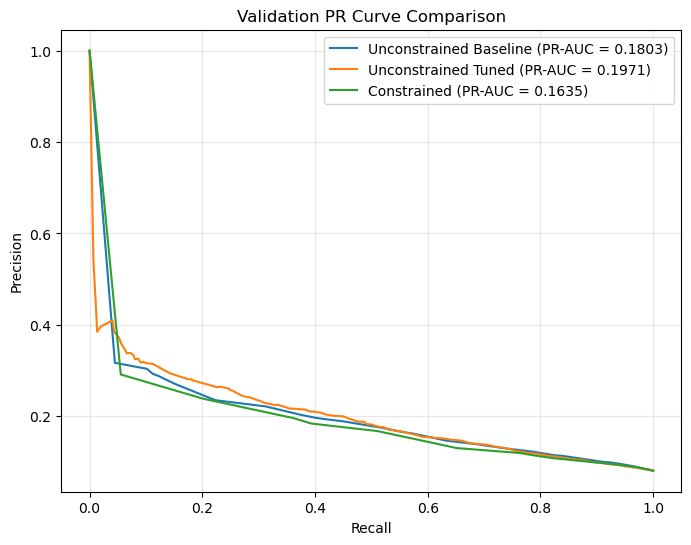

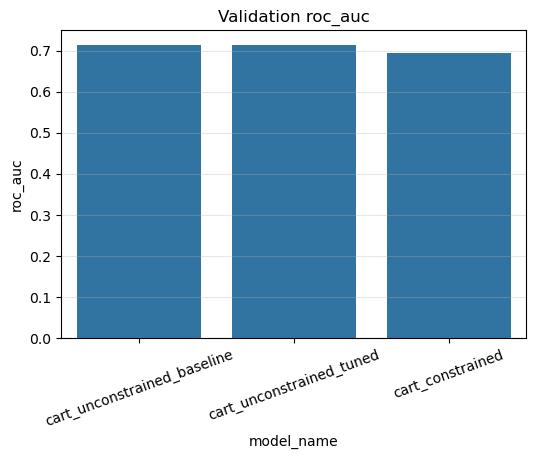

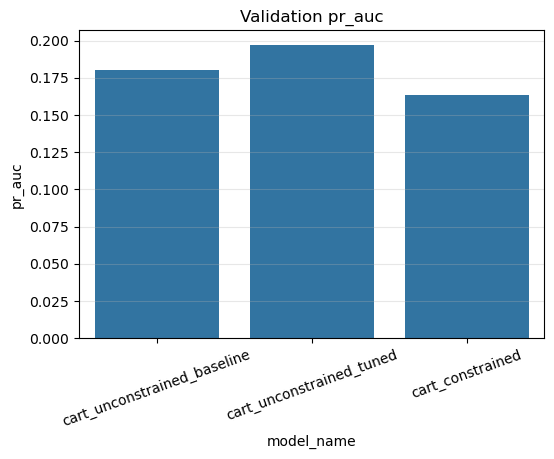

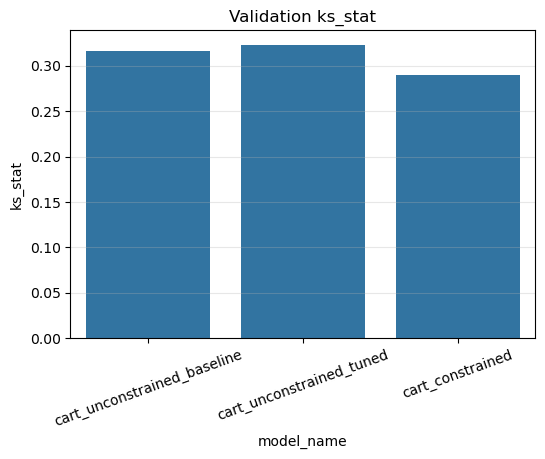

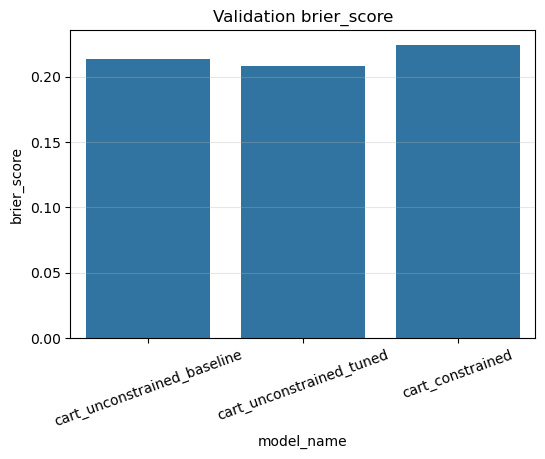

In [9]:
validation_compare_df = pd.DataFrame([baseline_val_result, tuned_val_result, constrained_val_result])
validation_compare_df.to_csv(VALIDATION_COMPARE_CSV, index=False)
display(validation_compare_df.head())

plot_pr_curves(
    curves_dict={
        "Unconstrained Baseline": (y_val, baseline_val_prob),
        "Unconstrained Tuned": (y_val, tuned_val_prob),
        "Constrained": (y_val, constrained_val_prob)
    },
    title="Validation PR Curve Comparison"
)

metrics_to_plot = ["roc_auc", "pr_auc", "ks_stat", "brier_score"]
for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=validation_compare_df, x="model_name", y=metric)
    plt.title(f"Validation {metric}")
    plt.xticks(rotation=20)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()


## MODEL TEST METRICS EVALUATION

Test Metrics Comparison:


,model_name,split,roc_auc,pr_auc,brier_score,ks_stat
0,cart_unconstrained_baseline,test,0.711936,0.179767,0.212802,0.313015
1,cart_unconstrained_tuned,test,0.709535,0.187437,0.207107,0.322619
2,cart_constrained,test,0.700361,0.165448,0.222687,0.292474


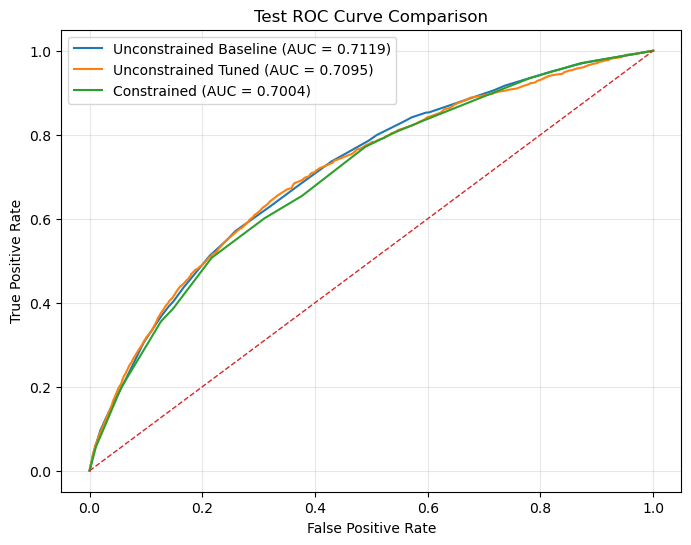

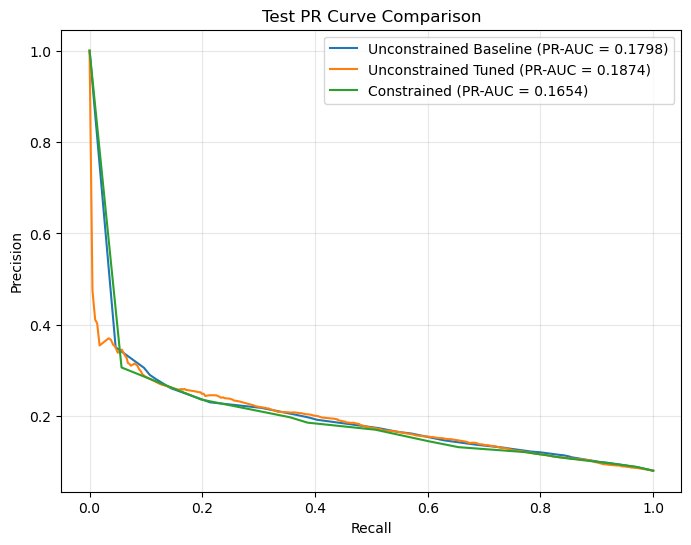

In [10]:
# Predict probabilities on Test Set
baseline_test_prob = cart_baseline.predict_proba(X_test_ready)[:, 1]
tuned_test_prob = best_cart_unconstrained.predict_proba(X_test_ready)[:, 1]
constrained_test_prob = best_cart_constrained.predict_proba(X_test_ready)[:, 1]

# Evaluate models on Test Set
baseline_test_result = evaluate_binary_model(cart_baseline, X_test_ready, y_test, "test", "cart_unconstrained_baseline")
tuned_test_result = evaluate_binary_model(best_cart_unconstrained, X_test_ready, y_test, "test", "cart_unconstrained_tuned")
constrained_test_result = evaluate_binary_model(best_cart_constrained, X_test_ready, y_test, "test", "cart_constrained")

test_compare_df = pd.DataFrame([baseline_test_result, tuned_test_result, constrained_test_result])
test_compare_df.to_csv(TEST_COMPARE_CSV, index=False)

print("Test Metrics Comparison:")
display(test_compare_df)

plot_roc_curves(
    curves_dict={
        "Unconstrained Baseline": (y_test, baseline_test_prob),
        "Unconstrained Tuned": (y_test, tuned_test_prob),
        "Constrained": (y_test, constrained_test_prob)
    },
    title="Test ROC Curve Comparison"
)

plot_pr_curves(
    curves_dict={
        "Unconstrained Baseline": (y_test, baseline_test_prob),
        "Unconstrained Tuned": (y_test, tuned_test_prob),
        "Constrained": (y_test, constrained_test_prob)
    },
    title="Test PR Curve Comparison"
)


## BUSINESS VIEWS (TEST SET)

We project performance onto the isolated TEST set to interpret dollar amounts based on mean credit amounts.

In [11]:
# Business View 1: Fixed Approval Rate (70%)
FIXED_APPROVAL_RATE = 0.70
tuned_fixed_approval = evaluate_operating_point(y_test, tuned_test_prob, approval_rate=FIXED_APPROVAL_RATE)
constrained_fixed_approval = evaluate_operating_point(y_test, constrained_test_prob, approval_rate=FIXED_APPROVAL_RATE)

fixed_approval_compare_df = pd.DataFrame([tuned_fixed_approval, constrained_fixed_approval], index=['cart_unconstrained_tuned', 'cart_constrained'])
fixed_approval_compare_df.to_csv(FIXED_APPROVAL_COMPARE_CSV, index=True)

defaults_diff = constrained_fixed_approval["approved_defaults"] - tuned_fixed_approval["approved_defaults"]
defaults_financial_impact = defaults_diff * MEAN_CREDIT_AMOUNT

print(f"Biz View 1 (Fixed 70% Approval Rate)")
print(f"Additional defaults admitted under constrained model: {defaults_diff}")
print(f"Estimated Capital Loss: ${defaults_financial_impact / 1e6:,.2f} M\n")

# Business View 2: Fixed Bad-Rate Target (5%)
SELECTED_BAD_RATE_TARGET = 0.05
tuned_fixed_bad_rate = evaluate_operating_point(y_test, tuned_test_prob, bad_rate_target=SELECTED_BAD_RATE_TARGET)
constrained_fixed_bad_rate = evaluate_operating_point(y_test, constrained_test_prob, bad_rate_target=SELECTED_BAD_RATE_TARGET)

fixed_bad_rate_compare_df = pd.DataFrame([tuned_fixed_bad_rate, constrained_fixed_bad_rate], index=['cart_unconstrained_tuned', 'cart_constrained'])
fixed_bad_rate_compare_df.to_csv(FIXED_BAD_RATE_COMPARE_CSV, index=True)

selected_unconstrained_approval_rate = tuned_fixed_bad_rate["approval_rate"]
selected_constrained_approval_rate = constrained_fixed_bad_rate["approval_rate"]
selected_approval_rate_diff = selected_unconstrained_approval_rate - selected_constrained_approval_rate

approved_applications_diff = tuned_fixed_bad_rate["n_approved"] - constrained_fixed_bad_rate["n_approved"]
opportunity_financial_impact = approved_applications_diff * MEAN_CREDIT_AMOUNT

print(f"Biz View 2 (Fixed 5% Bad Rate Target)")
print(f"Difference in Approval Rate: {selected_approval_rate_diff * 100:.2f}%")
print(f"Additional applications rejected under constrained model: {approved_applications_diff}")
print(f"Estimated Untapped Credit Volume (Upside Given Up): ${opportunity_financial_impact / 1e6:,.2f} M")

# Display Output DataFrame
biz_df = pd.DataFrame([
    {
        "scenario": f"Fixed {FIXED_APPROVAL_RATE*100}% approval rate",
        "unconstrained": tuned_fixed_approval["approved_defaults"],
        "constrained": constrained_fixed_approval["approved_defaults"],
        "gap (defaults/apps)": defaults_diff,
        "financial impact": f"${defaults_financial_impact / 1e6:,.2f} M",
        "interpretation": "Additional defaults admitted under constrained model (Loss)"
    },
    {
        "scenario": f"Fixed {SELECTED_BAD_RATE_TARGET*100}% bad-rate target",
        "unconstrained": tuned_fixed_bad_rate["n_approved"],
        "constrained": constrained_fixed_bad_rate["n_approved"],
        "gap (defaults/apps)": approved_applications_diff,
        "financial impact": f"${opportunity_financial_impact / 1e6:,.2f} M",
        "interpretation": "Additional applications rejected under constrained model (Opportunity Cost)"
    }
])
biz_df.to_csv(CART_BUSINESS_SUMMARY_CSV, index=False)
display(biz_df)


Biz View 1 (Fixed 70% Approval Rate)
Additional defaults admitted under constrained model: 65
Estimated Capital Loss: $38.95 M

Biz View 2 (Fixed 5% Bad Rate Target)
Difference in Approval Rate: 3.19%
Additional applications rejected under constrained model: 1471
Estimated Untapped Credit Volume (Upside Given Up): $881.40 M


,scenario,unconstrained,constrained,gap (defaults/apps),financial impact,interpretation
0,Fixed 70.0% approval rate,1546,1611,65,$38.95 M,Additional defaults admitted under constrained...
1,Fixed 5.0% bad-rate target,33853,32382,1471,$881.40 M,Additional applications rejected under constra...
